In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from scipy.io import loadmat

The Navier-Stokes equations in 2 dimensions are
$$\frac{\partial u}{\partial t} + \lambda_1 \left(u\frac{\partial u}{\partial x}+v\frac{\partial u}{\partial y}\right) = -\frac{\partial p}{\partial x} + \lambda_2 \left(\frac{\partial^2 u}{\partial x^2}+\frac{\partial^2 u}{\partial y^2}\right)$$
$$\frac{\partial v}{\partial t} + \lambda_1 \left(u\frac{\partial v}{\partial x}+v\frac{\partial v}{\partial y}\right) = -\frac{\partial p}{\partial y} + \lambda_2 \left(\frac{\partial^2 v}{\partial x^2}+\frac{\partial^2 v}{\partial y^2}\right)$$
where $(u,v)$ is the 2d velocity field, and $p$ is the pressure.

The continuity equation for incompressible fluids that describes the conservation of mass of the fluid implies that the divergence of the velocity field must be 0.
$$\frac{\partial u}{\partial x} + \frac{\partial v}{\partial y} = 0$$

We assume a vector potential $\psi(t,x,y)$ such that
$$u=\frac{\partial \psi}{\partial y}\ ;\ v=-\frac{\partial \psi}{\partial x}$$

Let's define the functions we want to go to zero:
$$f:=\frac{\partial u}{\partial t} + \lambda_1 \left(u\frac{\partial u}{\partial x}+v\frac{\partial u}{\partial y}\right) + \frac{\partial p}{\partial x} - \lambda_2 \left(\frac{\partial^2 u}{\partial x^2}+\frac{\partial^2 u}{\partial y^2}\right)$$
$$g:=\frac{\partial v}{\partial t} + \lambda_1 \left(u\frac{\partial v}{\partial x}+v\frac{\partial v}{\partial y}\right) + \frac{\partial p}{\partial y} - \lambda_2 \left(\frac{\partial^2 v}{\partial x^2}+\frac{\partial^2 v}{\partial y^2}\right)$$

We build a dense neural network that does
$$(t,x,y) \mapsto \left[\psi(t,x,y),p(t,x,y)\right] \mapsto \left[f(t,x,y),g(t,x,y)\right]$$

The loss functions are
$$L_{uv} = \frac{1}{N}\sum_{i=1}^N \left(|u(t^i,x^i,y^i)-u^i|^2+|v(t^i,x^i,y^i)-v^i|^2\right)$$
$$L_{fg} = \frac{1}{N}\sum_{i=1}^N \left(|f(t^i,x^i,y^i)|^2+|g(t^i,x^i,y^i)|^2\right)$$
$$L_\mathrm{total} = L_{uv} + \phi L_{fg}$$
where $\phi$ modulates the relative importance of the conservation equations.

In [2]:
file_name = '../data/cylinder_nektar_wake.mat'
data = loadmat(file_name)
        
U_star = data['U_star'] # N x 2 x T
P_star = data['p_star'] # N x T
t_star = data['t'] # T x 1
X_star = data['X_star'] # N x 2

N = X_star.shape[0]
T = t_star.shape[0]

XX = np.tile(X_star[:,0:1], (1,T)) # N x T
YY = np.tile(X_star[:,1:2], (1,T)) # N x T
TT = np.tile(t_star, (1,N)).T # N x T

UU = U_star[:,0,:] # N x T
VV = U_star[:,1,:] # N x T
PP = P_star # N x T

x = XX.flatten()[:,None] # NT x 1
y = YY.flatten()[:,None] # NT x 1
t = TT.flatten()[:,None] # NT x 1

u = UU.flatten()[:,None] # NT x 1
v = VV.flatten()[:,None] # NT x 1
p = PP.flatten()[:,None] # NT x 1

N, T

(5000, 200)

In [3]:
plt.style.use('dark_background')

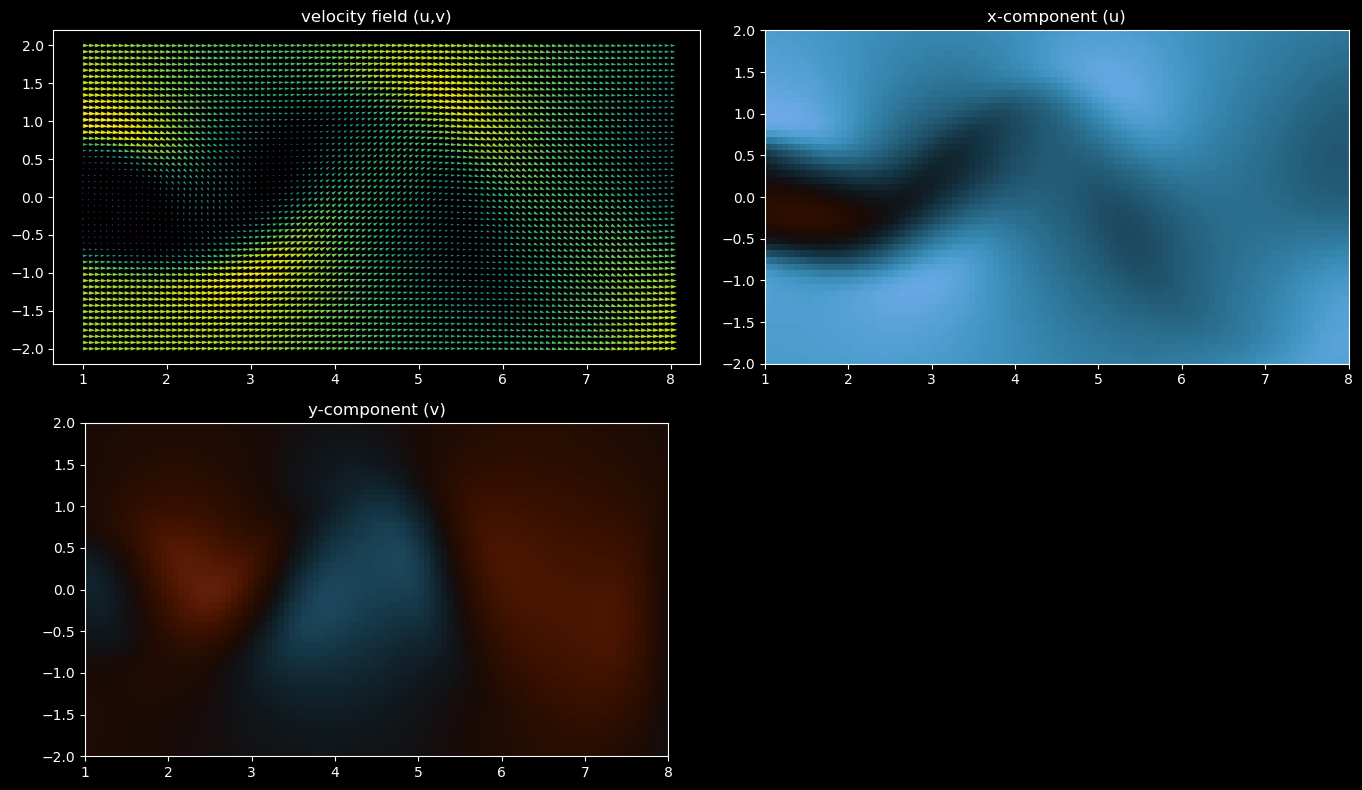

In [4]:
fig, ax = plt.subplots(2, 2, figsize=(7*2, 4*2), layout='tight')
ax[1,1].set_visible(False)
uv = ax[0,0].quiver(XX[:,100], YY[:,100], UU[:,100], VV[:,100], np.hypot(UU[:,100], VV[:,100]));
ax[0,0].set_title("velocity field (u,v)")
im_u = ax[0,1].imshow(UU[:,100].reshape(50, 100), cmap='berlin_r', vmin=-np.pi/2, vmax=np.pi/2, origin='lower', extent=(1, 8, -2, 2))
ax[0,1].set_title("x-component (u)")
im_v = ax[1,0].imshow(VV[:,100].reshape(50, 100), cmap='berlin_r', vmin=-np.pi/2, vmax=np.pi/2, origin='lower', extent=(1, 8, -2, 2))
ax[1,0].set_title("y-component (v)");

In [6]:
N_train = 5000
idx = np.random.choice(N*T, N_train, replace=False)
x_train = x[idx,:]
y_train = y[idx,:]
t_train = t[idx,:]
u_train = u[idx,:]
v_train = v[idx,:]

In [ ]:
class NeuralNetwork:
    def __init__(self, width, depth) -> None:
        self.f_factor = 1.  # relative importance of conservation equations
        self.model = self.get_model(width, depth)
        self.lambda_1 = tf.Variable([0.], trainable=True, dtype=tf.float32)
        self.lambda_2 = tf.Variable([0.], trainable=True, dtype=tf.float32)
        self.train_data = [t_train, x_train, y_train, u_train, v_train]
        self.train_data = [tf.convert_to_tensor(td.squeeze(), dtype=tf.float32) for td in self.train_data]
    
    def get_model(self, width, depth):
        model = keras.models.Sequential()
        model.add(keras.layers.InputLayer(shape=(3,)))
        for _ in range(depth):
            model.add(keras.layers.Dense(width, activation='tanh'))
        model.add(keras.layers.Dense(2, activation=None))
        return model
    
    def psi_p(self, t, x, y):
        return self.model(tf.stack([t, x, y], axis=-1))
    
    def u_v(self, t, x, y):
        with tf.GradientTape(persistent=True) as tape:
            tape.watch([t, x, y])
            psi = self.psi_p(t, x, y)[:,0]
        u, minus_v = tape.gradient(psi, [y, x])
        v = - minus_v
        return u, v
    
    def grads(self, t, x, y):
        with tf.GradientTape(persistent=True) as tape_outer:
            tape_outer.watch([t, x, y])
            with tf.GradientTape(persistent=True) as tape_mid:
                tape_mid.watch([t, x, y])
                with tf.GradientTape(persistent=True) as tape_inner:
                    tape_inner.watch([t, x, y])
                    psi_p = self.psi_p(t, x, y)
                    psi, p = psi_p[:,0], psi_p[:,1]
                u, minus_v = tape_inner.gradient(psi, [y, x])
                v = - minus_v
                px, py = tape_inner.gradient(p, [x, y])
            ut, ux, uy = tape_mid.gradient(u, [t, x, y])
            vt, vx, vy = tape_mid.gradient(v, [t, x, y])
        uxx = tape_outer.gradient(ux, x)
        uyy = tape_outer.gradient(uy, y)
        vxx = tape_outer.gradient(vx, x)
        vyy = tape_outer.gradient(vy, y)
        del tape_inner, tape_mid, tape_outer
        return u, ut, ux, uxx, uy, uyy, v, vt, vx, vxx, vy, vyy, px, py
    
    def f_g(self, t, x, y):
        u, ut, ux, uxx, uy, uyy, v, vt, vx, vxx, vy, vyy, px, py = self.grads(t, x, y)
        f = ut + self.lambda_1 * (u*ux+v*uy) + px - self.lambda_2 * (uxx+uyy)
        g = vt + self.lambda_1 * (u*vx+v*vy) + py - self.lambda_2 * (vxx+vyy)
        return u, v, f, g
    
    def get_loss(self, t, x, y, u, v):
        u_NN, v_NN, f, g = self.f_g(t, x, y)
        loss_uv = tf.reduce_mean(tf.square(u_NN - u)) + tf.reduce_mean(tf.square(v_NN - v))
        loss_fg = tf.reduce_mean(tf.square(f)) + tf.reduce_mean(tf.square(g))
        loss = loss_uv + self.f_factor * loss_fg
        return loss, loss_uv, loss_fg

    @tf.function
    def train_step(self, optimizer):
        with tf.GradientTape() as tape:
            loss, loss_uv, loss_fg = self.get_loss(*self.train_data)
        variables_to_train = self.model.trainable_variables + [self.lambda_1, self.lambda_2]
        grads = tape.gradient(loss, variables_to_train)
        optimizer.apply_gradients(zip(grads, variables_to_train))
        return loss, loss_uv, loss_fg
    
    def show_field(self, title=''):
        fig, ax = plt.subplots(2, 2, figsize=(7*2, 4*2), layout='tight')
        ax[1,1].axis('off')

        u, v = self.u_v(
            tf.convert_to_tensor(TT[:,100], dtype=tf.float32),
            tf.convert_to_tensor(XX[:,100], dtype=tf.float32),
            tf.convert_to_tensor(YY[:,100], dtype=tf.float32),
        )
        u = u.numpy()
        v = v.numpy()
        uv = ax[0,0].quiver(XX[:,100], YY[:,100], u, v, np.hypot(u, v))
        ax[0,0].set_title("velocity field (u,v)")
        im_u = ax[0,1].imshow(u.reshape(50, 100), cmap='berlin_r', vmin=-np.pi/2, vmax=np.pi/2, origin='lower', extent=(1, 8, -2, 2))
        ax[0,1].set_title("x-component (u)")
        im_v = ax[1,0].imshow(v.reshape(50, 100), cmap='berlin_r', vmin=-np.pi/2, vmax=np.pi/2, origin='lower', extent=(1, 8, -2, 2))
        ax[1,0].set_title("y-component (v)")
        ax[1,1].text(0.5, 0.5, title, ha='center', va='center', size=20)
        plt.colorbar(im_u, ax=ax[1,1])
        return fig, ax
    
    def show_field_diff(self, title=''):
        fig, ax = plt.subplots(2, 2, figsize=(7*2, 4*2), layout='tight')
        ax[1,1].axis('off')

        u, v = self.u_v(
            tf.convert_to_tensor(TT[:,100], dtype=tf.float32),
            tf.convert_to_tensor(XX[:,100], dtype=tf.float32),
            tf.convert_to_tensor(YY[:,100], dtype=tf.float32),
        )
        u = u.numpy() - UU[:,100]
        v = v.numpy() - VV[:,100]
        uv = ax[0,0].quiver(XX[:,100], YY[:,100], u, v, np.hypot(u, v))
        ax[0,0].set_title("velocity field (u,v)")
        im_u = ax[0,1].imshow(u.reshape(50, 100), cmap='berlin_r', vmin=-np.pi/2, vmax=np.pi/2, origin='lower', extent=(1, 8, -2, 2))
        ax[0,1].set_title("x-component (u)")
        im_v = ax[1,0].imshow(v.reshape(50, 100), cmap='berlin_r', vmin=-np.pi/2, vmax=np.pi/2, origin='lower', extent=(1, 8, -2, 2))
        ax[1,0].set_title("y-component (v)")
        ax[1,1].text(0.5, 0.5, title+" minus truth", ha='center', va='center', size=20)
        plt.colorbar(im_u, ax=ax[1,1])
        return fig, ax
    
    def show_pressure_potential(self, title=''):
        fig, ax = plt.subplots(2, 2, figsize=(7*2, 4*2), layout='tight')
        ax[1,1].axis('off')

        psi_p = self.psi_p(
            tf.convert_to_tensor(TT[:,100], dtype=tf.float32),
            tf.convert_to_tensor(XX[:,100], dtype=tf.float32),
            tf.convert_to_tensor(YY[:,100], dtype=tf.float32),
        )
        psi = psi_p[:,0].numpy()
        p = psi_p[:,1].numpy()

        max_p = max(max(p-min(p)), max(PP[:,100]-min(PP[:,100])))
        max_psi = max(psi-min(psi))
        
        im_p_nn = ax[0,0].imshow((p-min(p)).reshape(50, 100), cmap='viridis', vmin=0, vmax=max_p, origin='lower', extent=(1, 8, -2, 2))
        ax[0,0].set_title("pressure (NN)")
        im_p_tr = ax[0,1].imshow((PP[:,100]-min(PP[:,100])).reshape(50, 100), cmap='viridis', vmin=0, vmax=max_p, origin='lower', extent=(1, 8, -2, 2))
        ax[0,1].set_title("pressure (truth)")
        im_psi = ax[1,0].imshow((psi-min(psi)).reshape(50, 100), cmap='viridis', vmin=0, vmax=max_psi, origin='lower', extent=(1, 8, -2, 2))
        ax[1,0].set_title("potential (NN)")
        ax[1,1].text(0.5, 0.5, title, ha='center', va='center', size=20)
        plt.colorbar(im_p_nn)
        plt.colorbar(im_p_tr)
        plt.colorbar(im_psi)
        return fig, ax

In [8]:
neural_network = NeuralNetwork(width=20, depth=8)
_ = neural_network.model(tf.zeros((1, 3), dtype=tf.float32))

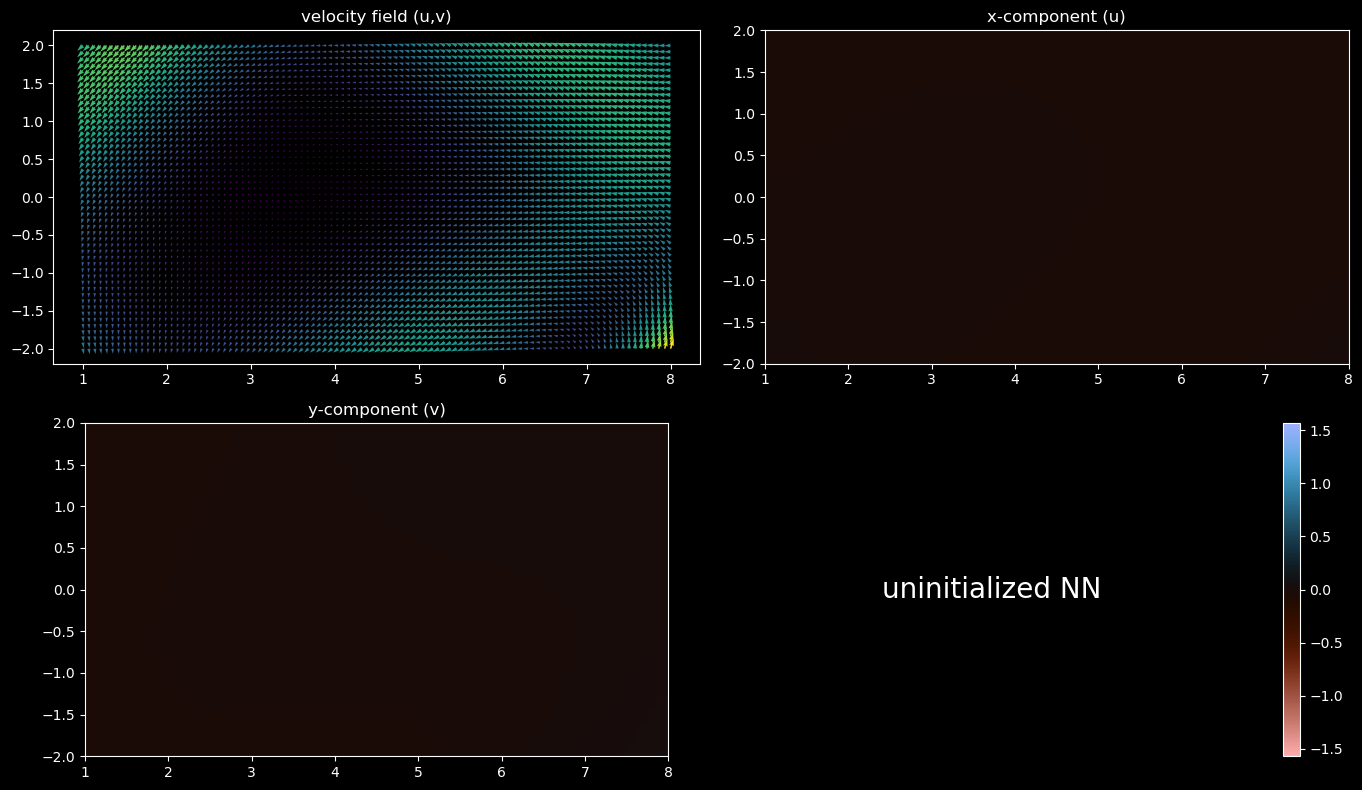

In [9]:
neural_network.show_field("uninitialized NN");

In [10]:
# optimizer = keras.optimizers.SGD(learning_rate=0.02)
optimizer = keras.optimizers.Adam(learning_rate=1e-3)
neural_network.model.compile(optimizer)

In [11]:
EPOCHS = 10_000
history = {"loss": [], "loss_uv": [], "loss_fg": []}
for epoch in range(1, EPOCHS + 1):
    loss, loss_uv, loss_fg = neural_network.train_step(optimizer)
    history["loss"].append(float(loss))
    history["loss_uv"].append(float(loss_uv))
    history["loss_fg"].append(float(loss_fg))
    if epoch % 500 == 0 or epoch == 1:
        print(f"epoch {epoch:5d} | loss {loss:.4e} | loss_uv {loss_uv:.2e} | loss_fg {loss_fg:.2e}")
    if epoch % 2000 == 0:
        new_LR = optimizer.learning_rate.numpy() / 2
        optimizer.learning_rate.assign(new_LR)

c:\Users\sange\anaconda3\envs\tf\Lib\site-packages\keras\src\optimizers\base_optimizer.py:857: UserWarning: Gradients do not exist for variables ['sequential/dense_8/bias'] when minimizing the loss. If using `model.compile()`, did you forget to provide a `loss` argument?
  warnings.warn(


epoch     1 | loss 8.6614e-01 | loss_uv 8.62e-01 | loss_fg 4.19e-03
epoch   500 | loss 7.1027e-02 | loss_uv 6.62e-02 | loss_fg 4.80e-03
epoch  1000 | loss 5.6115e-02 | loss_uv 5.26e-02 | loss_fg 3.49e-03
epoch  1500 | loss 4.9055e-02 | loss_uv 4.56e-02 | loss_fg 3.48e-03
epoch  2000 | loss 4.8392e-02 | loss_uv 4.49e-02 | loss_fg 3.46e-03
epoch  2500 | loss 3.7836e-02 | loss_uv 3.40e-02 | loss_fg 3.88e-03
epoch  3000 | loss 3.4367e-02 | loss_uv 3.03e-02 | loss_fg 4.08e-03
epoch  3500 | loss 3.1845e-02 | loss_uv 2.79e-02 | loss_fg 3.97e-03
epoch  4000 | loss 2.9838e-02 | loss_uv 2.55e-02 | loss_fg 4.30e-03
epoch  4500 | loss 2.8066e-02 | loss_uv 2.40e-02 | loss_fg 4.07e-03
epoch  5000 | loss 2.6611e-02 | loss_uv 2.26e-02 | loss_fg 4.02e-03
epoch  5500 | loss 2.5077e-02 | loss_uv 2.11e-02 | loss_fg 3.96e-03
epoch  6000 | loss 2.3415e-02 | loss_uv 1.95e-02 | loss_fg 3.88e-03
epoch  6500 | loss 2.2331e-02 | loss_uv 1.85e-02 | loss_fg 3.85e-03
epoch  7000 | loss 2.0733e-02 | loss_uv 1.69e-02

Ignore the UserWarning: Gradients do not exist for variables ['sequential_?/dense_?/bias'] when minimizing the loss.

Since the loss function involves only the gradients of $\psi$ and $p$, any change in the bias of the last layer has no effect on our calculations. For example,
$$\frac{\partial}{\partial x}\psi(x) = \frac{\partial}{\partial x}\left(\psi(x)+b\right)$$

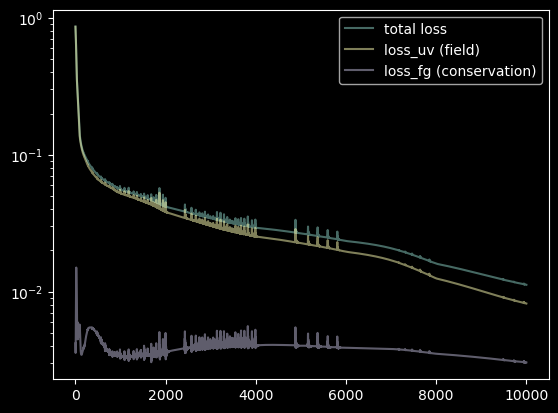

In [12]:
plt.yscale('log')
plt.plot(history['loss'], alpha=0.5, label='total loss')
plt.plot(history['loss_uv'], alpha=0.5, label='loss_uv (field)')
plt.plot(history['loss_fg'], alpha=0.5, label='loss_fg (conservation)')
plt.legend();

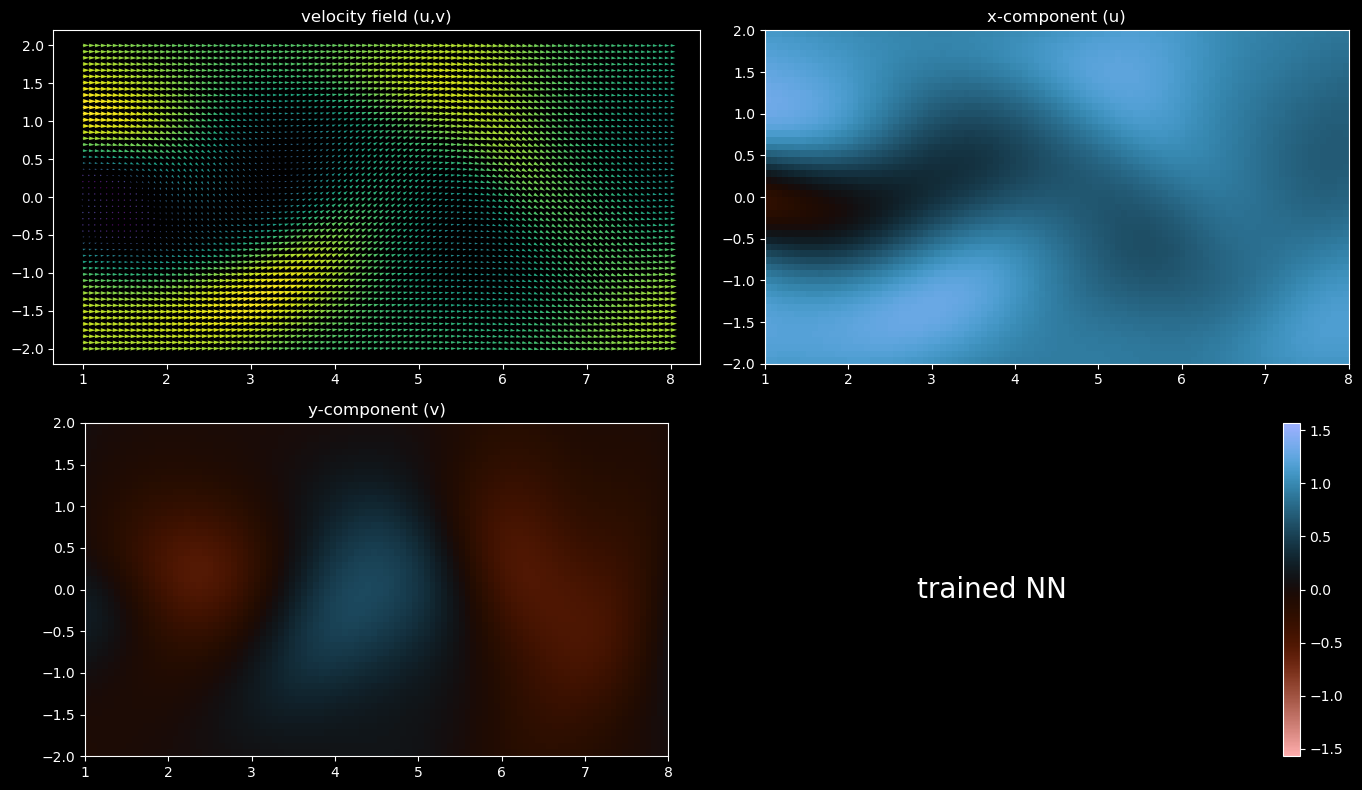

In [13]:
neural_network.show_field("trained NN");

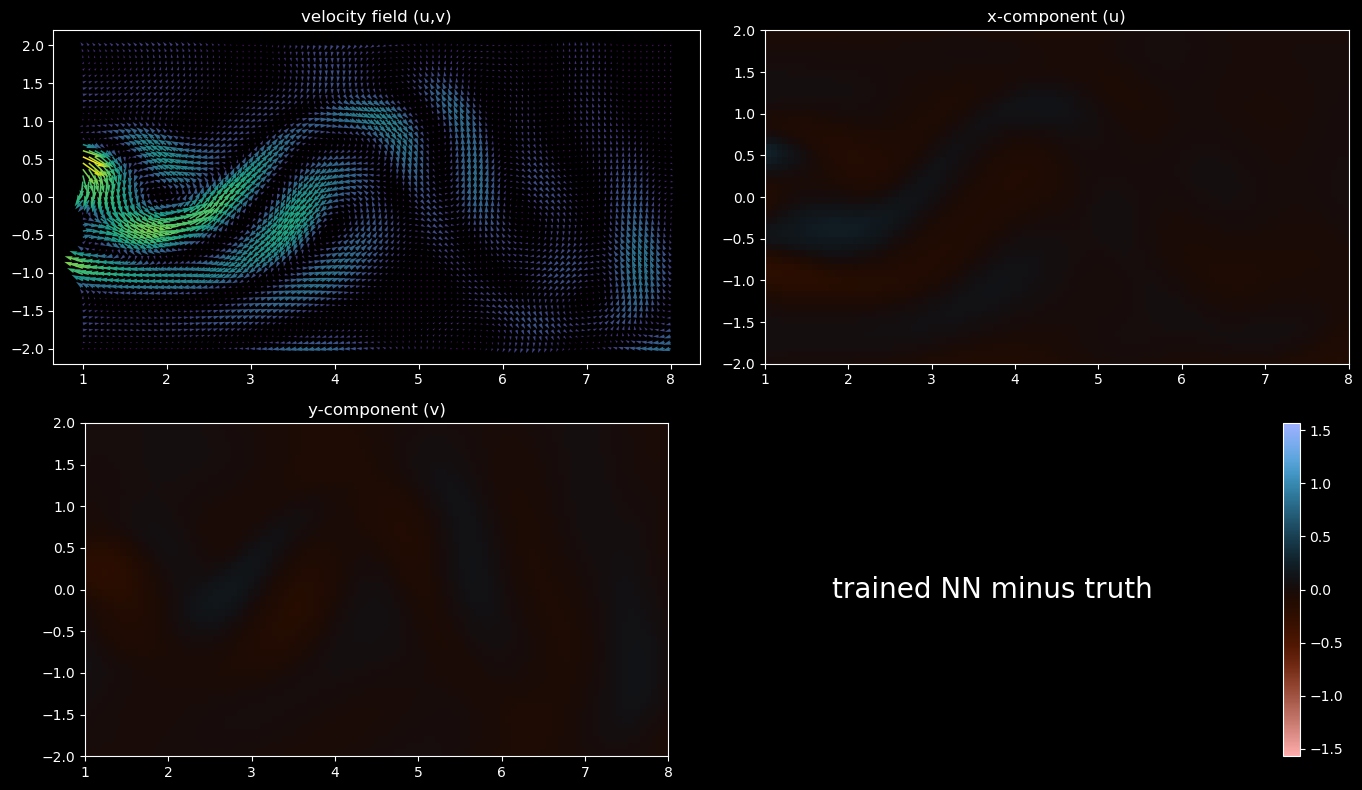

In [ ]:
neural_network.show_field_diff("trained NN");

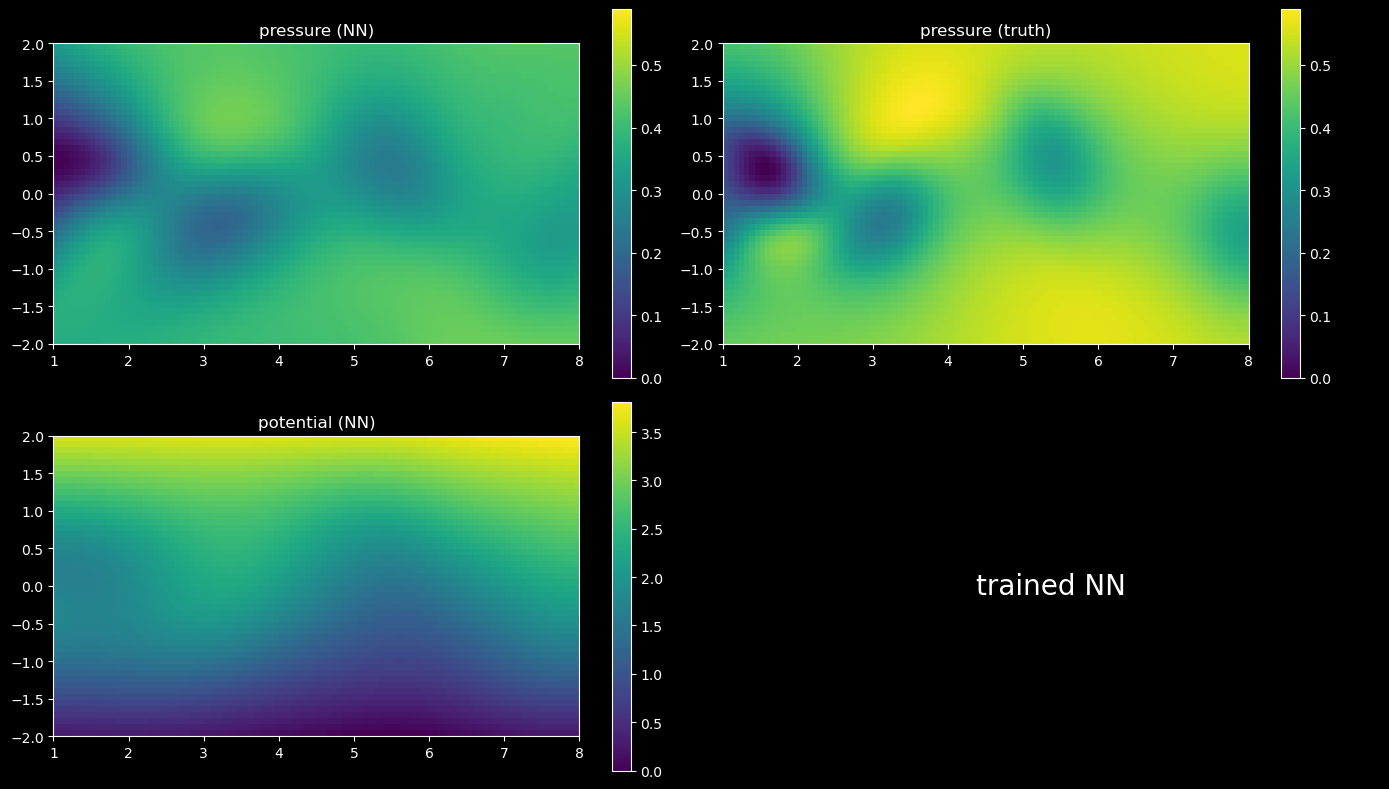

In [16]:
neural_network.show_pressure_potential("trained NN");

In [5]:
# from matplotlib.animation import FuncAnimation
# from IPython.display import HTML

# fig, ax = plt.subplots(2, 2, figsize=(7*2, 4*2), layout='tight')
# ax[1,1].set_visible(False)
# uv = ax[0,0].quiver(XX[:,0], YY[:,0], UU[:,0], VV[:,0], np.hypot(UU[:,0], VV[:,0]));
# ax[0,0].set_title("velocity field (u,v)")
# im_u = ax[0,1].imshow(UU[:,0].reshape(50, 100), cmap='berlin_r', vmin=-np.pi/2, vmax=np.pi/2, origin='lower', extent=(1, 8, -2, 2), animated=True)
# ax[0,1].set_title("x-component (u)")
# im_v = ax[1,0].imshow(VV[:,0].reshape(50, 100), cmap='berlin_r', vmin=-np.pi/2, vmax=np.pi/2, origin='lower', extent=(1, 8, -2, 2), animated=True)
# ax[1,0].set_title("y-component (v)");

# def update(frame):
#     uv.set_UVC(UU[:,frame], VV[:,frame], np.hypot(UU[:,frame], VV[:,frame]))
#     im_u.set_data(UU[:,frame].reshape(50, 100))
#     im_v.set_data(VV[:,frame].reshape(50, 100))
#     return uv, im_u, im_v

# anim = FuncAnimation(fig, update, frames=200, interval=100, blit=True)

# plt.close()  # Prevents static snapshot from displaying
# HTML(anim.to_jshtml())
# # anim.save("test_NS.gif", writer="pillow", fps=10, dpi=80)

In [19]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

fig, ax = plt.subplots(2, 2, figsize=(7*2, 4*2), layout='tight')
ax[1,1].axis('off')

u, v = neural_network.u_v(
    tf.convert_to_tensor(TT[:,0], dtype=tf.float32),
    tf.convert_to_tensor(XX[:,0], dtype=tf.float32),
    tf.convert_to_tensor(YY[:,0], dtype=tf.float32),
)
u = u.numpy()
v = v.numpy()
uv = ax[0,0].quiver(XX[:,0], YY[:,0], u, v, np.hypot(u, v))
ax[0,0].set_title("velocity field (u,v)")
im_u = ax[0,1].imshow(u.reshape(50, 100), cmap='berlin_r', vmin=-np.pi/2, vmax=np.pi/2, origin='lower', extent=(1, 8, -2, 2), animated=True)
ax[0,1].set_title("x-component (u)")
im_v = ax[1,0].imshow(v.reshape(50, 100), cmap='berlin_r', vmin=-np.pi/2, vmax=np.pi/2, origin='lower', extent=(1, 8, -2, 2), animated=True)
ax[1,0].set_title("y-component (v)")
ax[1,1].text(0.5, 0.5, 'Navier-Stokes\ntrained NN', ha='center', va='center', size=20)

def update(frame):
    u, v = neural_network.u_v(
        tf.convert_to_tensor(TT[:,frame], dtype=tf.float32),
        tf.convert_to_tensor(XX[:,frame], dtype=tf.float32),
        tf.convert_to_tensor(YY[:,frame], dtype=tf.float32),
    )
    u = u.numpy()
    v = v.numpy()
    uv.set_UVC(u, v, np.hypot(u, v))
    im_u.set_data(u.reshape(50, 100))
    im_v.set_data(v.reshape(50, 100))
    return uv, im_u, im_v

anim = FuncAnimation(fig, update, frames=200, interval=100, blit=True)

plt.close()  # Prevents static snapshot from displaying
# HTML(anim.to_jshtml())
anim.save("../images/NS.gif", writer="pillow", fps=10)